# Detecção de Fraudes em Transações de Cartão de Crédito

**Projeto desenvolvido por:** Mari Primon

## Problema de Negócio

Instituições financeiras processam milhões de transações diariamente e estão sujeitas a perdas causadas por operações fraudulentas.

A detecção de fraudes exige identificar transações suspeitas sem gerar um volume excessivo de bloqueios indevidos de operações legítimas.

Nesse contexto, técnicas de Machine Learning podem auxiliar na identificação de padrões associados a transações fraudulentas, apoiando processos de análise e prevenção de fraudes.

## Objetivo do Projeto

Desenvolver um modelo de Machine Learning capaz de identificar padrões que
permitam diferenciar transações de cartão de crédito legítimas de
transações fraudulentas, utilizando dados históricos de transações. O projeto busca analisar os dados, identificar padrões relacionados às
fraudes e avaliar o desempenho do modelo na classificação das transações.

## Dataset

Para o projeto, será utilizado o dataset Credit Card Fraud Detection, composto por 284.807 transações, sendo 492 fraudulentas e 284.315 legítimas. A forte diferença entre as classes caracteriza um problema de desbalanceamento, aspecto que será considerado na preparação dos dados e principalmente na avaliação dos modelos.

As variáveis V1 a V28 são componentes resultantes de uma transformação por Análise de Componentes Principais (PCA), aplicada para preservar a confidencialidade das informações originais.

A variável Time representa o tempo decorrido desde a primeira transação registrada, enquanto Amount representa o valor da transação.

A variável Class é utilizada como variável-alvo:

0 → transação legítima
1 → transação fraudulenta

## Tecnologias Utilizadas

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn
* XGBoost
* SHAP

### Referência

A abordagem de avaliação de dados desbalanceados utilizada como referência neste projeto considera as recomendações apresentadas pelo tutorial oficial do TensorFlow sobre classificação em dados desbalanceados.

GOOGLE. TensorFlow Core. Classification on imbalanced data. Disponível em: https://www.tensorflow.org/tutorials/structured_data/imbalanced_data?hl=pt-br. Acesso em: 16 ago. 2026.

## 1° Análise Exploratória dos Dados

Antes da modelagem, os dados serão analisados para avaliar sua estrutura, qualidade, distribuição e características relevantes para o problema de classificação.

Essa etapa orienta as decisões de preparação dos dados e definição das estratégias de modelagem.


In [ ]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.shape

(284807, 31)

In [ ]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 2° Desbalanceamento das classes

A variável Class apresenta uma diferença significativa entre transações legítimas e fraudulentas.

Essa característica torna a acurácia insuficiente como única métrica de avaliação, pois um modelo pode apresentar alto desempenho aparente mesmo identificando poucas fraudes.



In [ ]:
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


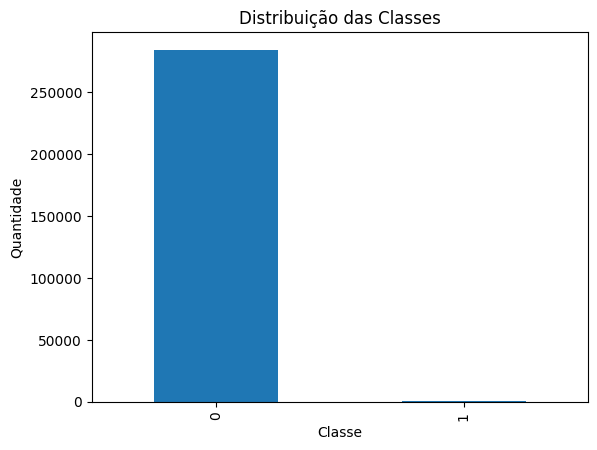

In [ ]:
import matplotlib.pyplot as plt

df["Class"].value_counts().plot(kind="bar")

plt.title("Distribuição das Classes")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

## Feature Engineering

As variáveis disponíveis no dataset serão analisadas para verificar se algumas transformações podem melhorar sua utilização pelo modelo.

Neste projeto, será aplicada uma transformação logarítmica na variável `Amount` para reduzir o impacto de valores muito altos. Também será utilizada a padronização quando necessária para colocar os valores em uma escala comparável.

O objetivo é preparar os dados para a etapa de modelagem sem alterar as informações originais das transações.


In [ ]:
## A transformação comprime valores muito altos e evita problemas com valores 0.

import numpy as np

df['Amount_log'] = np.log1p(df['Amount'])

In [ ]:
## Aplicando a técnica de padronização para deixar os dados com média 0 e
## desvio padrão 1, colocando os valores em uma escala comparável.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

## 4. Separação dos Dados

Os dados serão divididos em treino e teste para avaliar o modelo em transações que não foram utilizadas durante o treinamento.



In [ ]:
## Dividindo os dados em treino e teste para avaliar o modelo em dados que ele
## não utilizou durante o treinamento, mantendo a proporção das classes.

from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.3,
    random_state=42
)

##5. Avaliação dos Modelos

Serão testados diferentes modelos para comparar sua capacidade de identificar transações fraudulentas.

A Regressão Logística será utilizada como modelo inicial. Depois, serão avaliados Random Forest e XGBoost.

### Logistic Regression

A Regressão Logística será utilizada como modelo inicial para estabelecer uma referência de desempenho e comparar os resultados com os modelos seguintes.


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 6. Métricas de Avaliação

Como o dataset possui poucas transações fraudulentas em comparação às legítimas, a acurácia não será analisada sozinha.

O **Recall** será uma das principais métricas, pois mostra a capacidade do modelo de encontrar as fraudes. A **Precision** ajuda a avaliar quantas das transações classificadas como fraude realmente são fraudulentas.

O **F1-score** será utilizado para analisar o equilíbrio entre Precision e Recall.


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



### Resultado

A Regressão Logística apresentou **Recall de 0,66** para a classe fraudulenta. Isso significa que o modelo conseguiu identificar parte das fraudes, mas ainda deixou algumas transações fraudulentas sem identificação.

Esse resultado será utilizado como referência para comparar os próximos modelos.


### Curva ROC

A curva ROC permite analisar o desempenho do modelo considerando diferentes limites de classificação.


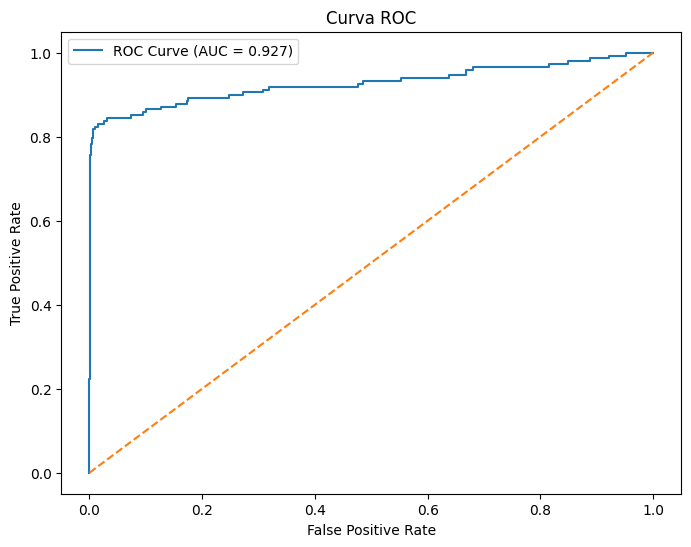

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtendo as probabilidades da classe positiva (fraude)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculando os pontos da curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculando a área sob a curva
roc_auc = auc(fpr, tpr)

# Plotando a curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

### Curva Precision-Recall

Como o dataset possui um grande desbalanceamento entre as classes, a curva Precision-Recall ajuda a analisar melhor o desempenho do modelo na identificação das fraudes.


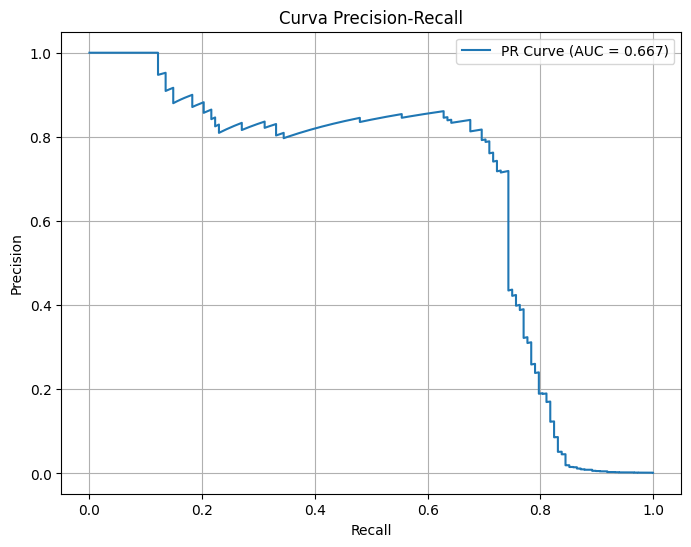

In [ ]:
# Em problemas com classes fortemente desbalanceadas, a curva Precision-Recall
# permite avaliar melhor a capacidade do modelo de identificar a classe minoritária (fraude),
# analisando o equilíbrio entre a detecção das fraudes e os falsos positivos.

from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Obtendo as probabilidades da classe positiva (fraude)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculando Precision e Recall para diferentes limiares
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Calculando a área sob a curva Precision-Recall
pr_auc = auc(recall, precision)

# Plotando a curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR Curve (AUC = {pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid()
plt.show()

## Balanceamento de Dados

In [ ]:
fraudes = df[df["Class"] == 1]
legitimas = df[df["Class"] == 0].sample(n=len(fraudes), random_state=42)

df_balanced = pd.concat([fraudes, legitimas]).sample(frac=1, random_state=42)

## 7. Random Forest

O Random Forest será testado para verificar se um modelo baseado em árvores consegue melhorar a identificação das fraudes em relação à Regressão Logística.

O parâmetro `class_weight="balanced"` será utilizado para dar maior importância à classe fraudulenta durante o treinamento.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



### Resultado

O Random Forest apresentou **Recall de 0,76**, superior aos **0,66** obtidos pela Regressão Logística.

O F1-score também aumentou de **0,73 para 0,79**, indicando uma melhora na identificação das fraudes.


In [ ]:
# Padronizando as variáveis antes da Regressão Logística para evitar influência das escalas.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [ ]:
# Reduzindo o limiar para aumentar a detecção de fraudes.
threshold = 0.2
y_pred_custom = (y_prob > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.75      0.72      0.73       148

    accuracy                           1.00     85443
   macro avg       0.87      0.86      0.87     85443
weighted avg       1.00      1.00      1.00     85443



## 8. XGBoost

O XGBoost será testado para verificar se um modelo de boosting consegue melhorar ainda mais os resultados obtidos pelos modelos anteriores.

O parâmetro `scale_pos_weight` será utilizado para considerar o desbalanceamento entre as classes.


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:38:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



### Resultado

O XGBoost apresentou o melhor desempenho entre os modelos avaliados,
alcançando **Recall de 0,78**, **Precision de 0,94** e **F1-score de 0,85**
para a classe fraudulenta.

## 10. Importância das Variáveis

A importância das variáveis permite observar quais características tiveram maior influência nas decisões do XGBoost.


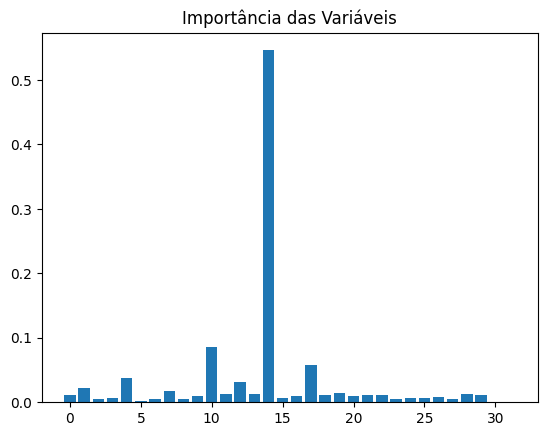

In [ ]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das Variáveis")
plt.show()

## 9. Comparação dos Modelos

A comparação permite identificar qual modelo apresentou o melhor resultado para a classe fraudulenta.

| Modelo              | Precision |   Recall | F1-score |
| ------------------- | --------: | -------: | -------: |
| Logistic Regression |      0,84 |     0,66 |     0,73 |
| Random Forest       |      0,84 |     0,76 |     0,79 |
| XGBoost             |  **0,94** | **0,78** | **0,85** |

O **XGBoost apresentou o melhor resultado**, com maior Precision, Recall e F1-score entre os modelos avaliados.


## 11. Ajuste de Hiperparâmetros

Após identificar o XGBoost como o melhor modelo, será realizado um teste com diferentes combinações de hiperparâmetros.

O **Recall** será utilizado como métrica de avaliação, buscando aumentar a identificação das transações fraudulentas.


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=10,
        eval_metric="logloss",
        random_state=42
    ),
    param_grid,
    scoring="recall",
    cv=3
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 3, 'n_estimators': 50}
0.8284515636918384


### Resultado

A melhor combinação encontrada foi `max_depth=3` e `n_estimators=50`,
alcançando um **Recall médio de 82,85%** na validação cruzada.

In [ ]:
from sklearn.metrics import classification_report

# Modelo com os melhores hiperparâmetros
best_model = grid.best_estimator_

# Previsões no conjunto de teste
y_pred_best = best_model.predict(X_test)

# Avaliação final
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.80      0.80      0.80       148

    accuracy                           1.00     85443
   macro avg       0.90      0.90      0.90     85443
weighted avg       1.00      1.00      1.00     85443



### Resultado Final

O modelo apresentou 80% de recall e 80% de F1-score para a classe de fraude, identificando corretamente a maior parte das transações fraudulentas. A acurácia de 100% deve ser interpretada com cautela devido ao desbalanceamento dos dados. Portanto, o recall e o F1-score da classe 1 (fraude) são as métricas mais relevantes para avaliar o desempenho do modelo.

## 13. Explicabilidade com SHAP

Além de avaliar o desempenho do modelo, é importante entender quais variáveis influenciam suas decisões.

O SHAP será utilizado para analisar a contribuição das variáveis nas previsões do XGBoost.


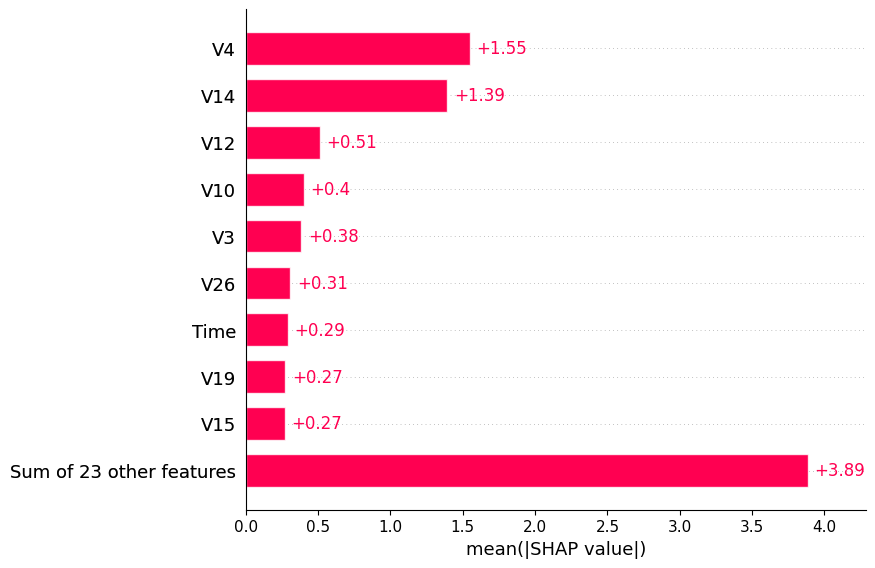

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

### Resultado da Explicabilidade

A análise com SHAP permitiu identificar quais variáveis tiveram maior influência nas decisões do modelo XGBoost. Dessa forma, além de apresentar um bom desempenho na detecção de fraudes, o modelo também pode ser interpretado, permitindo compreender quais características das transações mais contribuíram para suas previsões.

### Conclusão

O projeto apresentou a aplicação de técnicas de Machine Learning para a detecção de fraudes em transações de cartão de crédito. Foram avaliados os modelos Logistic Regression, Random Forest e XGBoost, considerando principalmente Precision, Recall e F1-score devido ao forte desbalanceamento das classes.

Entre os modelos avaliados inicialmente, o XGBoost apresentou o melhor desempenho, com Precision de 0,94, Recall de 0,78 e F1-score de 0,85 para a classe fraudulenta. Após o ajuste de hiperparâmetros, o modelo final apresentou Recall de 0,80 e F1-score de 0,80 no conjunto de teste.

A utilização do SHAP permitiu identificar quais variáveis apresentaram maior influência média nas previsões do XGBoost, contribuindo para uma melhor interpretação do comportamento do modelo.

Dessa forma, o projeto demonstra como técnicas de Machine Learning, ajuste de hiperparâmetros e explicabilidade podem ser utilizadas em conjunto para auxiliar na identificação de transações potencialmente fraudulentas.